In [26]:
from __future__ import annotations
import numpy as np
import random
import gymnasium as gym
import matplotlib.pyplot as plt

In [66]:

class FrozenLakeCustomReward(gym.Wrapper):
    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        if terminated and reward == 0.0:
            reward = -100.0
        elif terminated and reward == 1.0:
            reward = 1000.0
        else:
            reward = -10.0
        return obs, reward, terminated, truncated, info
def make_env(is_slippery=False):
  return gym.make(id='FrozenLake-v1', map_name='8x8', is_slippery=is_slippery)

In [67]:
env=make_env(is_slippery=False)

In [68]:
def epsilon_greedy(Q, state, nA, epsilon):
    if random.random() < epsilon:
        return random.randrange(nA) #exploration
    return int(np.argmax(Q[state])) #exploitation

In [69]:
def monte_carlo(env,policy,nA,nS,num_episodes=1000, gamma=0.09, theta=1e-5, MAX_STEPS=100):
  V_values=np.zeros((nS,2))
  for episode in range(num_episodes):
    visited_states=[]
    state=random.randint(0,nS-1)
    env.reset()
    env.unwrapped.s=state
    action=policy[state]
    done=False
    trajectory=[]
    for i in range(MAX_STEPS):
      next_state,reward,done,_,_= env.step(action)
      trajectory.append((state,reward))
      if done:
        break
      state=next_state
      action=policy[state]
    G=0
    for state,reward in reversed(trajectory):
      G=gamma*G+ reward
      if state not in visited_states:
        visited_states.append(state)
        V_values[state,0]+=G
        V_values[state,1]+=1
  return V_values[:,0]/np.maximum(V_values[:,1],1e-8)


In [70]:
import numpy as np
import random

def monte_carlo_control_off_policy(env, nA, nS, epsilon, num_episodes, gamma, MAX_STEPS):
    episode_rewards = []
    episode_lengths = []
    Q = np.zeros((nS, nA))
    C = np.zeros((nS, nA))
    pi = greedy_policy(Q)

    for episode in range(num_episodes):
        total_reward = 0
        episode_length = 0
        state = random.randint(0, nS - 1)
        env.reset()
        env.unwrapped.s = state

        done = False
        trajectory = []
        action = epsilon_greedy(Q, state, nA, epsilon)


        for i in range(MAX_STEPS):
            next_state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            episode_length += 1
            done = terminated or truncated


            current_best_action = np.argmax(Q[state])
            prob_greedy = (1.0 - epsilon) + (epsilon / nA)
            prob_random = epsilon / nA
            action_prob = prob_greedy if action == current_best_action else prob_random

            trajectory.append((state, action, reward, action_prob))

            if done:
                break

            state = next_state
            action = epsilon_greedy(Q, state, nA, epsilon)
        G = 0.0
        W = 1.0
        for state, action, reward, action_prob in reversed(trajectory):
            G = gamma * G + reward
            C[state, action] += W
            Q[state, action] += (W / C[state, action]) * (G - Q[state, action])

            pi[state] = np.argmax(Q[state])
            if action != pi[state]:
                break

            W = W / action_prob
        episode_rewards.append(total_reward)
        episode_lengths.append(episode_length)

    return Q, pi , episode_rewards, episode_lengths

In [71]:
import numpy as np
import random

def monte_carlo_control(env, nA, nS, epsilon, num_episodes, gamma, MAX_STEPS):
    episode_lengths=[]
    episode_rewards=[]
    Q = np.zeros((nS, nA))
    N = np.zeros((nS, nA))
    for episode in range(num_episodes):
        total_reward=0
        episode_length=0
        visited_states = set()
        state = random.randint(0, nS - 1)
        env.reset()
        env.unwrapped.s = state
        action = epsilon_greedy(Q, state, nA, epsilon)
        done=False
        trajectory = []
        for i in range(MAX_STEPS):
            next_state, reward, terminated, truncated, _ = env.step(action)
            total_reward+=reward
            episode_length+=1
            done=terminated or truncated
            trajectory.append((state, action, reward))
            if done:
                break
            state = next_state
            action = epsilon_greedy(Q, state, nA, epsilon)
        G = 0
        for state, action, reward in reversed(trajectory):
            G = gamma * G + reward
            if (state, action) not in visited_states:
                visited_states.add((state, action))
                N[state, action] += 1
                Q[state, action] += (G - Q[state, action]) / N[state, action]
        episode_rewards.append(total_reward)
        episode_lengths.append(episode_length)
    return Q,episode_rewards,episode_lengths

In [72]:
def greedy_policy(Q_values):
  return np.argmax(Q_values,axis=1)
#this will return a policy that contains the best action for each state

In [73]:
def plot_policy_on_frozen_lake(env, policy, title="FrozenLake policy"):
	desc = np.asarray(env.unwrapped.desc, dtype=str)
	policy_grid = np.asarray(policy).reshape(desc.shape)
	arrows = np.array(["<", "v", ">", "^"])
	colors = {
		"S": "#9be7a1",
		"F": "#dceefb",
		"H": "#3a3a3a",
		"G": "#ffd54f",
	}

	fig, ax = plt.subplots(figsize=(8, 8))
	for r in range(desc.shape[0]):
		for c in range(desc.shape[1]):
			tile = desc[r, c]
			rect = plt.Rectangle((c, desc.shape[0] - 1 - r), 1, 1, facecolor=colors[tile], edgecolor="black", linewidth=1.5)
			ax.add_patch(rect)

			if tile == "H":
				label = "H"
			elif tile == "G":
				label = "G"
			elif tile == "S":
				label = f"S{arrows[policy_grid[r, c]]}"
			else:
				label = arrows[policy_grid[r, c]]

			ax.text(c + 0.5, desc.shape[0] - 1 - r + 0.5, label, ha="center", va="center", fontsize=16, fontweight="bold", color="black")

	ax.set_xlim(0, desc.shape[1])
	ax.set_ylim(0, desc.shape[0])
	ax.set_xticks(np.arange(desc.shape[1] + 1))
	ax.set_yticks(np.arange(desc.shape[0] + 1))
	ax.grid(True, color="black", linewidth=1.0)
	ax.set_xticklabels([])
	ax.set_yticklabels([])
	ax.set_aspect("equal")
	ax.set_title(title)
	plt.tight_layout()
	plt.show()

Learned policy (action per state):
[[3 2 2 2 2 1 2 1]
 [2 2 2 2 2 2 3 1]
 [3 3 3 0 2 2 2 1]
 [3 3 2 2 3 0 2 1]
 [3 3 3 0 2 2 2 1]
 [3 0 0 2 2 1 0 1]
 [3 0 2 3 0 1 0 1]
 [3 1 3 0 2 2 2 0]]

State values V(s):
[[0.    0.869 0.878 0.886 0.895 0.904 0.932 0.941]
 [0.869 0.878 0.886 0.895 0.904 0.914 0.923 0.951]
 [0.86  0.869 0.878 0.    0.932 0.941 0.951 0.961]
 [0.851 0.86  0.904 0.914 0.923 0.    0.961 0.97 ]
 [0.843 0.851 0.895 0.    0.951 0.961 0.97  0.98 ]
 [0.835 0.    0.    0.951 0.961 0.97  0.    0.99 ]
 [0.826 0.    0.932 0.941 0.    0.98  0.    1.   ]
 [0.818 0.    0.923 0.    0.98  0.99  1.    0.   ]]


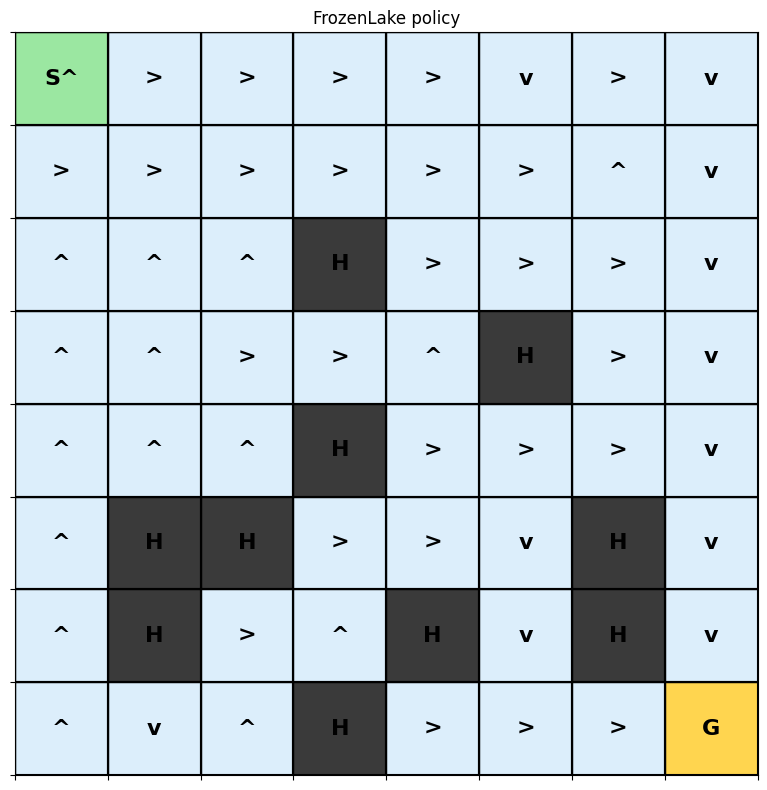

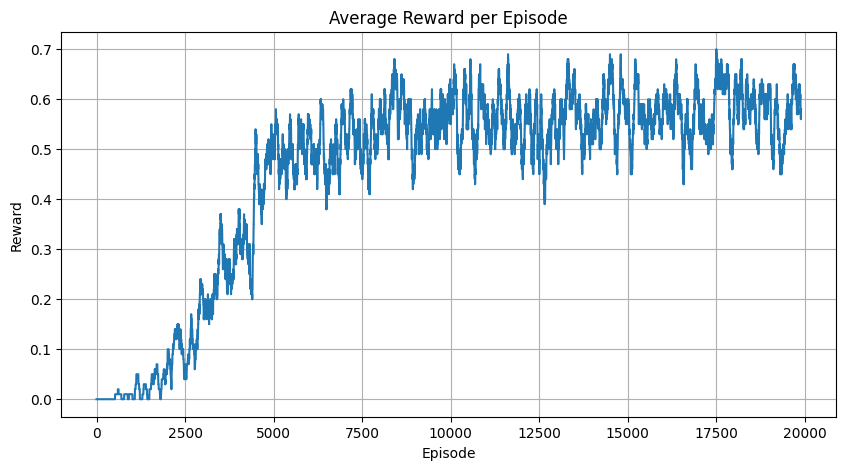

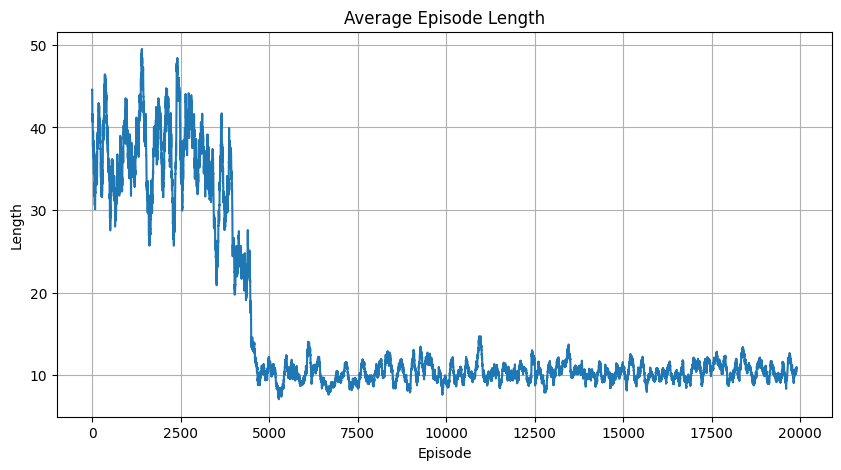

In [74]:
def main():#main function for on policy

    nS = env.observation_space.n
    nA = env.action_space.n
    gamma = 0.99
    epsilon = 0.3
    num_episodes = 20000
    MAX_STEPS = 300
    Q ,episode_rewards,episode_length= monte_carlo_control(env,nA,nS,epsilon=epsilon, num_episodes=num_episodes,gamma=gamma, MAX_STEPS=MAX_STEPS )
    policy = greedy_policy(Q)
    print("Learned policy (action per state):")
    print(policy.reshape(8, 8))
    V = monte_carlo(env, policy, nA, nS, gamma=gamma,
                    num_episodes=num_episodes, MAX_STEPS=MAX_STEPS)
    print("\nState values V(s):")
    print(np.round(V.reshape(8, 8), 3))
    env.close()
    plot_policy_on_frozen_lake(env, policy)
    window = 100

    avg_rewards = np.convolve(
        episode_rewards,
        np.ones(window) / window,
        mode="valid"
    )

    plt.figure(figsize=(10,5))
    plt.plot(avg_rewards)
    plt.title("Average Reward per Episode")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.grid(True)
    plt.show()
    avg_lengths = np.convolve(
    episode_length,
    np.ones(window) / window,
    mode="valid"
   )

    plt.figure(figsize=(10,5))
    plt.plot(avg_lengths)
    plt.title("Average Episode Length")
    plt.xlabel("Episode")
    plt.ylabel("Length")
    plt.grid(True)
    plt.show()



if __name__ == "__main__":
    main()

Learned target policy (action per state):
[[0 1 2 2 1 1 0 0]
 [3 2 2 2 1 0 0 0]
 [2 2 1 0 2 2 1 1]
 [3 3 2 2 1 0 2 1]
 [3 2 3 0 2 2 2 1]
 [3 0 0 2 2 3 0 1]
 [3 0 2 3 0 1 0 1]
 [3 2 0 0 2 2 2 0]]

State values V(s):
[[0.    0.886 0.895 0.904 0.914 0.904 0.895 0.886]
 [0.    0.895 0.904 0.914 0.923 0.914 0.904 0.895]
 [0.895 0.904 0.914 0.    0.932 0.941 0.951 0.961]
 [0.886 0.895 0.923 0.932 0.941 0.    0.961 0.97 ]
 [0.878 0.904 0.914 0.    0.951 0.961 0.97  0.98 ]
 [0.869 0.    0.    0.932 0.941 0.951 0.    0.99 ]
 [0.86  0.    0.914 0.923 0.    0.98  0.    1.   ]
 [0.851 0.    0.    0.    0.98  0.99  1.    0.   ]]


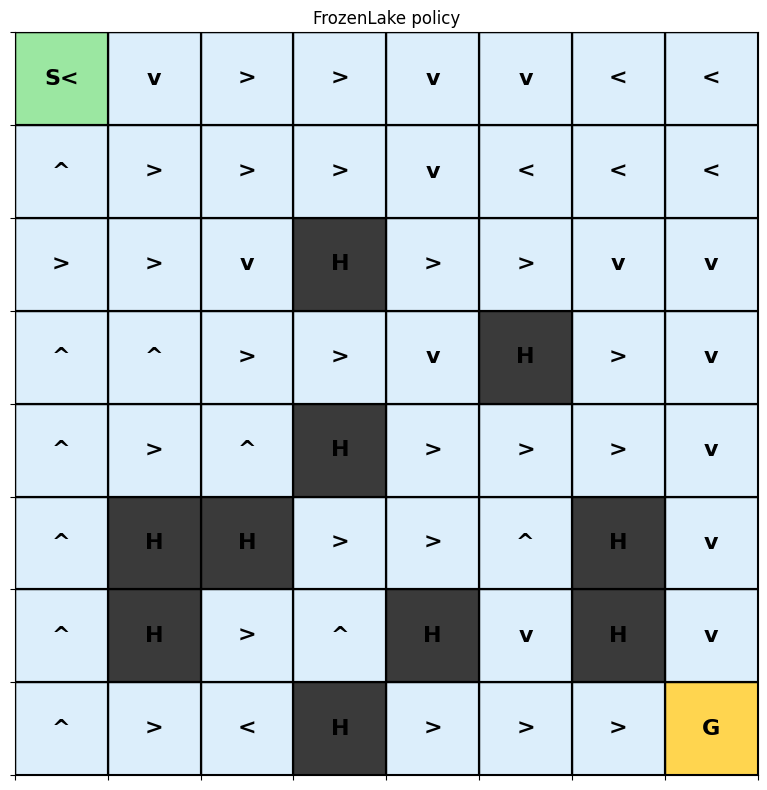

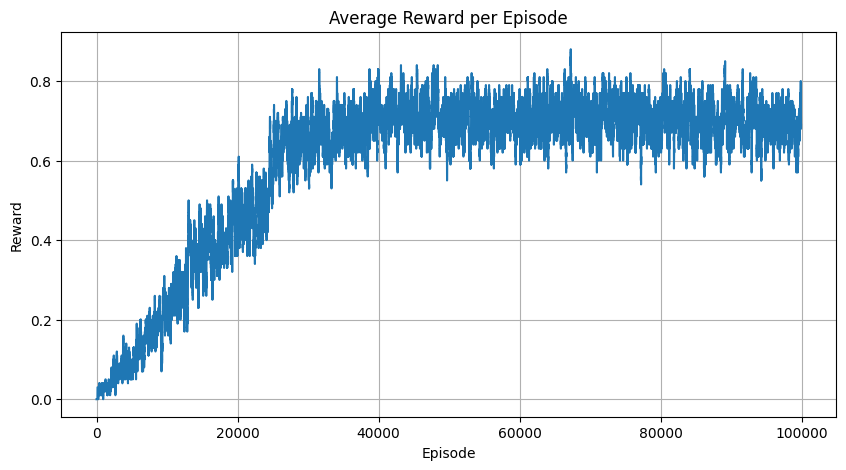

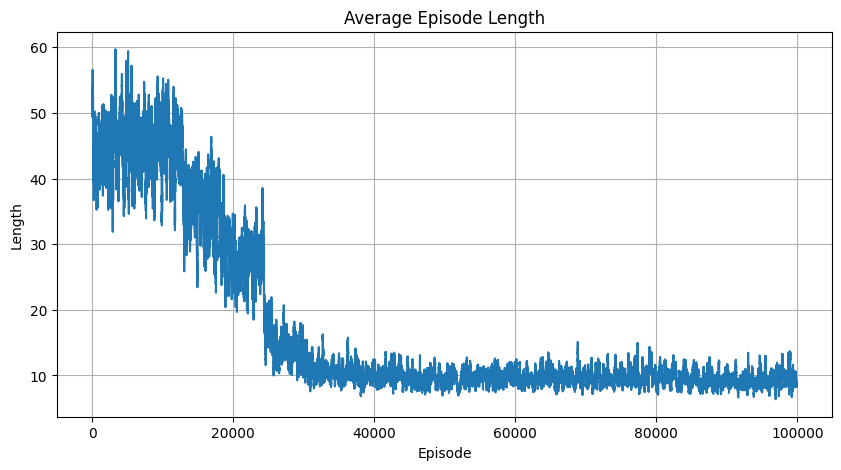

In [75]:
def main(): # main function for off policy

    nS = env.observation_space.n
    nA = env.action_space.n
    gamma = 0.99
    epsilon = 0.1
    num_episodes = 100000
    MAX_STEPS = 100
    Q, policy ,episode_rewards, episode_length= monte_carlo_control_off_policy(
        env, nA, nS, epsilon=epsilon, num_episodes=num_episodes, gamma=gamma, MAX_STEPS=MAX_STEPS
    )
    print("Learned target policy (action per state):")
    print(policy.reshape(8, 8))
    V = monte_carlo(env, policy, nA, nS, gamma=gamma,
                    num_episodes=num_episodes, MAX_STEPS=MAX_STEPS)

    print("\nState values V(s):")
    print(np.round(V.reshape(8, 8), 3))

    env.close()
    plot_policy_on_frozen_lake(env, policy)
    window = 100

    avg_rewards = np.convolve(
        episode_rewards,
        np.ones(window) / window,
        mode="valid"
    )

    plt.figure(figsize=(10,5))
    plt.plot(avg_rewards)
    plt.title("Average Reward per Episode")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.grid(True)
    plt.show()
    avg_lengths = np.convolve(
    episode_length,
    np.ones(window) / window,
    mode="valid"
   )

    plt.figure(figsize=(10,5))
    plt.plot(avg_lengths)
    plt.title("Average Episode Length")
    plt.xlabel("Episode")
    plt.ylabel("Length")
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    main()